In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import oracledb
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

load_dotenv()
warnings.filterwarnings('ignore')

c:\Users\vitor\Data_Projects\EC2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
CONNECT_STRING = '(description= (retry_count=20)(retry_delay=3)(address=(protocol=tcps)(port=1522)(host=adb.sa-saopaulo-1.oraclecloud.com))(connect_data=(service_name=g253a13c6f2211a_dadosaiopslocaweb_low.adb.oraclecloud.com))(security=(ssl_server_dn_match=yes)))'

def conectar_oracle():
    return oracledb.connect(
        user=DB_USER,
        password=DB_PASSWORD,
        dsn=CONNECT_STRING,
        wallet_location=r"C:/opt/OracleCloud/Wallet_dadosAIOpsLocaweb",
        wallet_password=DB_PASSWORD
    )

In [3]:
# Ler dados de uma view do banco de dados oracle
df = pd.read_sql_query("SELECT * FROM admin.VIEW_INCIDENTES_P2_P3", con=conectar_oracle())

In [4]:
df.shape

(57381, 18)

In [5]:
df.sample(50)

,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,DT_RESOLVIDO,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
11629,2 - Alta,Nao Informado,Nao Informado,Nao Informado,Team14,IC00502,2025-12-01 23:19:49,NaT,2025-12-01 23:53:20,2011,Em andamento,Problem: Unavailable by ICMP ping,Nenhuma,Monitoramento,INC8618742,Sem Intervenção,NAO,NAO
48438,3 - Média,lcem,cat76,sub285,Team05,IC08010,2025-04-17 08:10:51,2025-04-17 08:26:43,2025-04-22 01:00:39,952,Falha de Aplicação,Problem: NFS Client service /storage/8 is unmo...,Nenhuma,Monitoramento,INC8361245,Encerrado Automaticamente,NAO,NAO
3110,2 - Alta,lrev,cat97,sub95,Team14,IC00767,2025-12-23 02:27:20,2025-12-23 02:42:45,2025-12-23 02:49:28,925,Falha de Aplicação,"Problem: Service ""MESMTPCS (MESMTPCS) is not r...",Contorno,Monitoramento,NaN,Encerrado,SIM,NAO
57146,2 - Alta,lcho,cat85,sub307,Team14,IC02697,2025-01-09 11:55:36,2025-01-09 12:19:31,2025-01-09 12:32:31,1435,Falha de Cloud,[IC02697] Servidor desativado,Nenhuma,Manual,NaN,Encerrado,SIM,NAO
6232,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00171,2025-12-22 11:11:29,NaT,2025-12-22 11:23:54,745,Em andamento,Problem: Disk I/O is overloaded on IC00171,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
7738,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team05,IC01138,2025-12-18 14:54:00,NaT,2025-12-18 14:56:40,160,Em andamento,Problem: Lack of available swap memory on serv...,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
34120,3 - Média,lcem,cat76,sub392,Team05,IC06493,2025-08-26 23:19:09,2025-08-26 23:52:41,2025-08-31 01:01:38,2012,Incidente causado por Change,Problem: Check wiggumd_catchall_port on Port 2...,Definitiva,Monitoramento,INC8514135,Encerrado Automaticamente,NAO,NAO
42997,3 - Média,lhco,cat71,sub427,Team09,IC00181,2025-05-18 08:31:50,2025-05-18 14:26:39,2025-05-23 01:00:38,21289,Falha de Storage,Problem: Free Disk Space is less than 10% on v...,Nenhuma,Monitoramento,NaN,Encerrado Automaticamente,SIM,NAO
37293,3 - Média,lcem,cat76,sub438,Team05,IC02678,2025-07-14 19:22:04,2025-07-14 21:50:17,2025-07-19 01:01:38,8893,Falha de Aplicação,Problem: CPU is running in 90%,Nenhuma,Monitoramento,NaN,Encerrado Automaticamente,SIM,NAO
11300,2 - Alta,Nao Informado,Nao Informado,Nao Informado,Team14,IC01450,2025-12-03 15:30:25,NaT,2025-12-03 15:32:52,147,Em andamento,Problem: Unavailable by ICMP ping,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO


In [6]:
print(df['DT_ABERTO'].min())
print("\n",df['DT_ABERTO'].max())


2023-01-02 20:19:58

 2025-12-31 23:45:18


In [7]:
df2 = df.copy()

In [8]:
df2.dtypes

TP_PRIORIDADE                      str
NM_PRODUTO                         str
NM_CATEGORIA                       str
NM_SUBCATEGORIA                    str
NM_GRUPO_DESIGNADO                 str
NM_ITEM_CONFIGURACAO               str
DT_ABERTO               datetime64[us]
DT_RESOLVIDO            datetime64[us]
DT_ENCERRADO            datetime64[us]
NR_DURACAO                       int64
CD_FECHAMENTO                      str
DS_RESUMIDA                        str
TP_SOLUCAO                         str
TP_ABERTO_POR                      str
CD_INCIDENTE_PAI                   str
TP_STATUS                          str
FL_KPI                             str
FL_KPI_VIOLADO                     str
dtype: object

In [9]:
df2.dtypes

TP_PRIORIDADE                      str
NM_PRODUTO                         str
NM_CATEGORIA                       str
NM_SUBCATEGORIA                    str
NM_GRUPO_DESIGNADO                 str
NM_ITEM_CONFIGURACAO               str
DT_ABERTO               datetime64[us]
DT_RESOLVIDO            datetime64[us]
DT_ENCERRADO            datetime64[us]
NR_DURACAO                       int64
CD_FECHAMENTO                      str
DS_RESUMIDA                        str
TP_SOLUCAO                         str
TP_ABERTO_POR                      str
CD_INCIDENTE_PAI                   str
TP_STATUS                          str
FL_KPI                             str
FL_KPI_VIOLADO                     str
dtype: object

In [10]:
mudanca_prioridade = {
    "2 - Alta": 2,
    "3 - Média": 3,    
}

df2["TP_PRIORIDADE"] = df["TP_PRIORIDADE"].map(mudanca_prioridade)
df2["TP_PRIORIDADE"].value_counts()

TP_PRIORIDADE
3    41732
2    15649
Name: count, dtype: int64

In [11]:
df2["FL_KPI_VIOLADO"].value_counts()

FL_KPI_VIOLADO
NAO    52873
SIM     4508
Name: count, dtype: int64

In [12]:
df2[df2["FL_KPI_VIOLADO"] == "SIM"]

,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,DT_RESOLVIDO,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
117,2,lsd0,cat85,sub307,Team14,IC00090,2025-12-31 08:31:17,2025-12-31 14:38:40,2025-12-31 14:43:02,22043,Falha de Cloud,[vps57635] POOL Fora do ar - IC00166,Contorno,Manual,INC8653593,Encerrado,NAO,SIM
334,2,lsin,cat141,sub446,Team03,IC00166,2025-12-31 04:19:30,2025-12-31 14:16:11,2025-12-31 14:44:14,35801,Falha de Hardware,Problem: Unavailable by ICMP ping,Definitiva,Monitoramento,NaN,Encerrado,SIM,SIM
652,3,lsmt,cat46,sub31,Team05,IC00277,2025-12-30 06:42:20,NaT,2025-12-31 11:11:34,102554,Em andamento,Problem: Check PMTA IC00622 Queue,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,SIM
1501,3,lhco,cat71,sub427,Team09,IC00433,2025-12-28 08:09:00,NaT,2025-12-29 12:40:31,102691,Outro,Problem: Free Disk Space is less than 10% on v...,Definitiva,Monitoramento,NaN,Encerrado,SIM,SIM
1551,3,lhco,cat18,sub36,Team14,IC00429,2025-12-28 14:18:35,2025-12-29 17:30:56,2025-12-29 19:15:08,97941,Outro,[Bacula Backup] Restore incompleto do Backup ...,Definitiva,Manual,NaN,Encerrado,SIM,SIM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57376,3,lcem,cat91,sub12,Team11,IC00604,2024-10-01 16:11:08,2025-07-08 08:56:22,2025-07-13 01:00:13,24165914,Em andamento,Falha no painel | vectorcontainersIC04172com,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM
57377,3,lcsi,cat41,sub152,Team14,IC00725,2024-10-01 13:19:06,2025-11-25 15:40:08,2025-11-30 01:00:31,36296462,Falha de Aplicação,Falha na publicação de site - ttconsultoriaspe...,Definitiva,Manual,NaN,Encerrado Automaticamente,SIM,SIM
57378,3,lhco,cat85,sub206,Team11,IC07218,2024-09-30 17:12:43,2025-07-08 08:55:34,2025-07-13 01:00:12,24248571,Falha de Aplicação,Inside Sales | Normandia | Falha na Ativação –...,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM
57379,3,lcem,cat91,sub12,Team05,IC00604,2024-09-28 11:41:15,2025-02-18 09:23:49,2025-02-23 01:00:13,12346954,Falha de Aplicação,Falha ao excluir apelido no painel de e-mail,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM


# Sazonalidade e Tendência

In [13]:
df2.dtypes

TP_PRIORIDADE                    int64
NM_PRODUTO                         str
NM_CATEGORIA                       str
NM_SUBCATEGORIA                    str
NM_GRUPO_DESIGNADO                 str
NM_ITEM_CONFIGURACAO               str
DT_ABERTO               datetime64[us]
DT_RESOLVIDO            datetime64[us]
DT_ENCERRADO            datetime64[us]
NR_DURACAO                       int64
CD_FECHAMENTO                      str
DS_RESUMIDA                        str
TP_SOLUCAO                         str
TP_ABERTO_POR                      str
CD_INCIDENTE_PAI                   str
TP_STATUS                          str
FL_KPI                             str
FL_KPI_VIOLADO                     str
dtype: object

In [14]:
df2['DATA'] = df2['DT_ABERTO'].dt.date

In [15]:
# agrupar volume de incidentes por dia
datas_agrupadas = []

for data in df2['DATA'].unique():
    datas_agrupadas.append([data, len(df2[df2['DATA'] == data])])

incidentes_dt = pd.DataFrame(datas_agrupadas, columns=["data", "qtd_incidentes"])

In [16]:
incidentes_dt.shape

(608, 2)

In [17]:
incidentes_dt = incidentes_dt.sort_values(by='data').reset_index()

In [18]:
incidentes_dt.drop(columns='index', inplace=True)

In [19]:
incidentes_dt

,data,qtd_incidentes
0,2023-01-02,1
1,2023-01-09,1
2,2023-01-11,2
3,2023-01-16,1
4,2023-01-17,2
...,...,...
603,2025-12-27,555
604,2025-12-28,437
605,2025-12-29,572
606,2025-12-30,497


## 2024-12-27 index 238

In [20]:
incidentes_dt.tail(10)

,data,qtd_incidentes
598,2025-12-22,805
599,2025-12-23,648
600,2025-12-24,551
601,2025-12-25,399
602,2025-12-26,454
603,2025-12-27,555
604,2025-12-28,437
605,2025-12-29,572
606,2025-12-30,497
607,2025-12-31,387


<Axes: xlabel='data'>

<Figure size 1200x600 with 0 Axes>

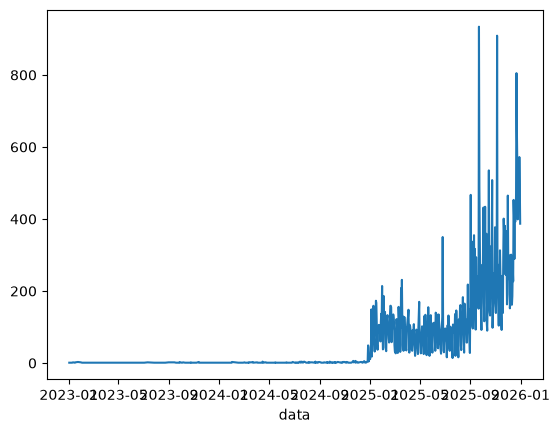

In [21]:
plt.figure(figsize=(12,6))
incidentes_dt.plot(legend=False, x='data')

In [22]:
df_inc2 = incidentes_dt.copy()

In [23]:
df_inc2 = df_inc2[238:]

In [24]:
df_inc2.shape

(370, 2)

<Axes: xlabel='data'>

<Figure size 1200x600 with 0 Axes>

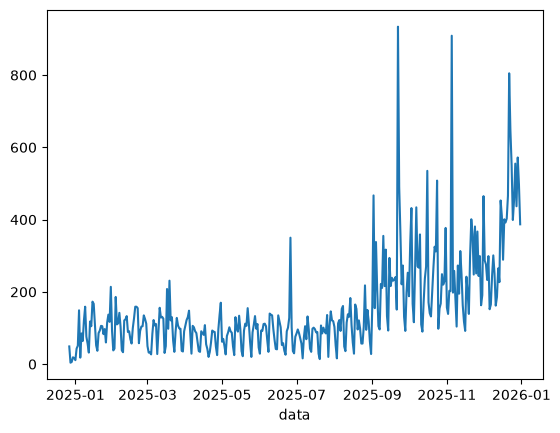

In [25]:
plt.figure(figsize=(12,6))
df_inc2.plot(legend=False, x='data')

In [26]:
df_inc2.set_index('data', drop=True, inplace=True)

In [27]:
df_inc2.head(10)

,qtd_incidentes
data,
2024-12-27,49
2024-12-28,4
2024-12-29,6
2024-12-30,19
2024-12-31,17
2025-01-01,11
2025-01-02,43
2025-01-03,51
2025-01-04,149


## Verificando estacionariedade

In [28]:
# Adfuller
teste_adf = adfuller(df_inc2)
print('Estatistica ADF: {0:.4f}'.format(teste_adf[0]))
print('p-valor: {0:.4f}'.format(teste_adf[1]))

if teste_adf[1] < 0.05:
    print("Rejeitamos a hipótese nula de que a série temporal possui raiz unitária (não estacionária). Portanto, concluímos que a série é estacionária.")
else:
    print("Não rejeitamos a hipótese nula, ou seja, não há evidências suficientes para afirmar que a série é estacionária.")


Estatistica ADF: 0.6133
p-valor: 0.9879
Não rejeitamos a hipótese nula, ou seja, não há evidências suficientes para afirmar que a série é estacionária.


## Integrated (d)

In [29]:
## Tecnica das primeiras diferencas

teste_adf = adfuller(df_inc2['qtd_incidentes'].diff().dropna())
print('Estatistica ADF: {0:.4f}'.format(teste_adf[0]))
print('p-valor: {0:.4f}'.format(teste_adf[1]))

if teste_adf[1] < 0.05:
    print("Rejeitamos a hipótese nula de que a série temporal possui raiz unitária (não estacionária). Portanto, concluímos que a série é estacionária.")
else:
    print("Não rejeitamos a hipótese nula, ou seja, não há evidências suficientes para afirmar que a série é estacionária.")

Estatistica ADF: -9.1402
p-valor: 0.0000
Rejeitamos a hipótese nula de que a série temporal possui raiz unitária (não estacionária). Portanto, concluímos que a série é estacionária.


<Axes: xlabel='data'>

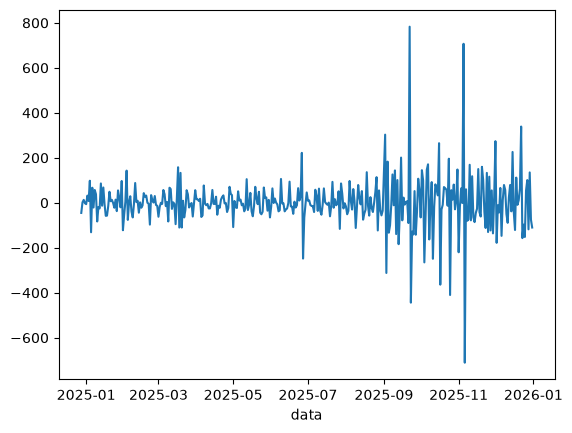

In [30]:
df_inc2['qtd_incidentes'].diff().dropna().plot(legend=False)

## PACF

In [31]:
df_inc2.shape

(370, 1)

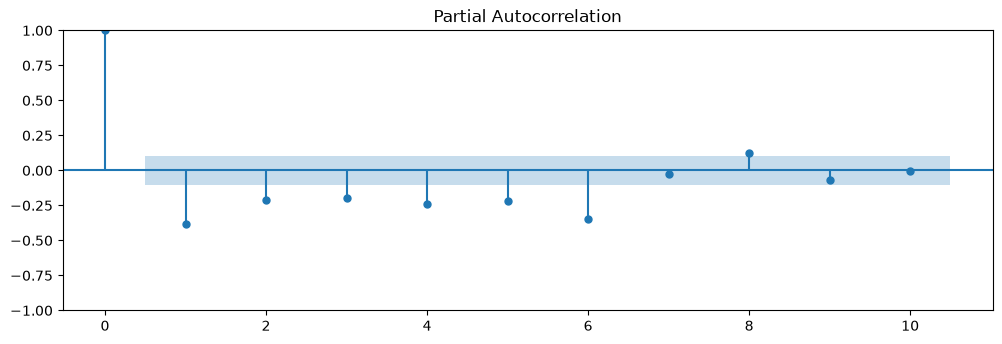

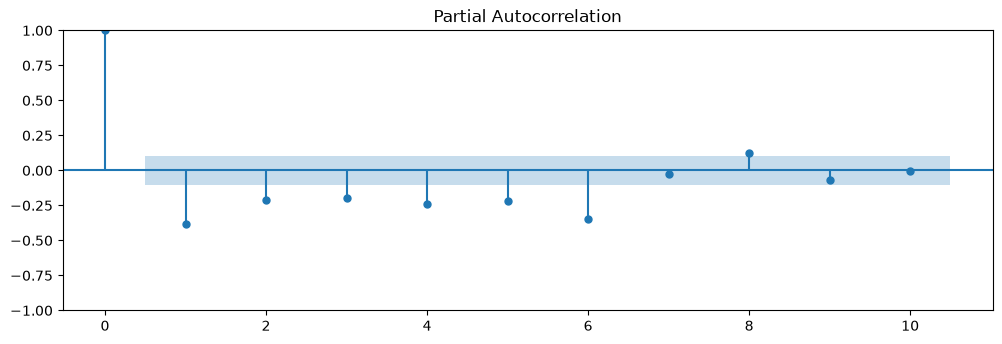

In [32]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
plot_pacf(df_inc2['qtd_incidentes'].diff().dropna(), lags= 10, ax= ax1)

## ACF

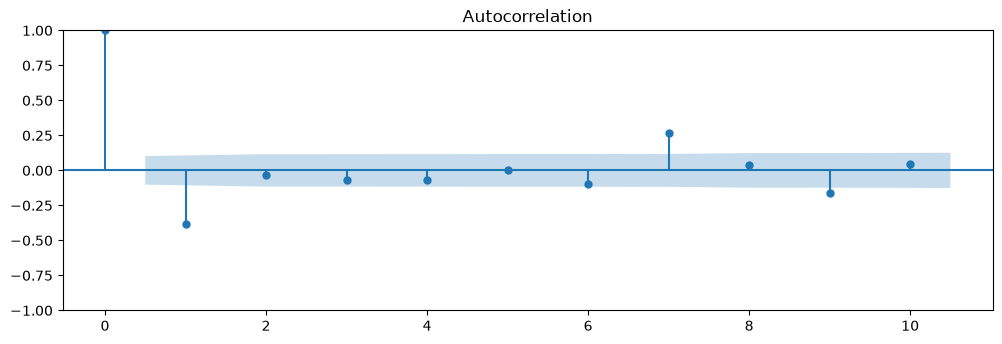

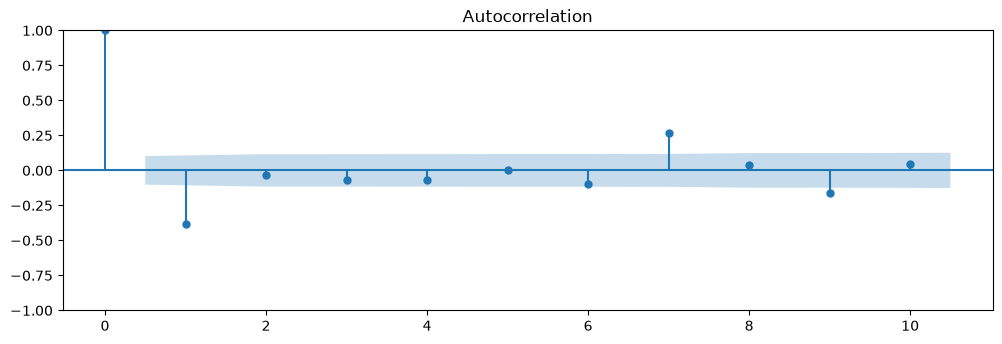

In [33]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
plot_acf(df_inc2['qtd_incidentes'].diff().dropna(), lags= 10, ax= ax1)

## Divisão Teste e Treino

In [34]:
df_inc3 = df_inc2['qtd_incidentes'].diff().dropna(inplace=True)

In [35]:
df_inc2.shape

(370, 1)

In [36]:
tam_teste = 30
treino = df_inc2[:-tam_teste]
teste = df_inc2[-tam_teste:]

print(f"Dados de treino: {len(treino)} dias")
print(f"Dados de teste: {len(teste)} dias")

Dados de treino: 340 dias
Dados de teste: 30 dias


In [37]:
treino

,qtd_incidentes
data,
2024-12-27,49
2024-12-28,4
2024-12-29,6
2024-12-30,19
2024-12-31,17
...,...
2025-11-27,244
2025-11-28,299
2025-11-29,163


In [38]:
teste

,qtd_incidentes
data,
2025-12-02,287
2025-12-03,276
2025-12-04,233
2025-12-05,299
2025-12-06,152
2025-12-07,165
2025-12-08,244
2025-12-09,301
2025-12-10,251


## ARIMA(7,1,6)

In [39]:
## Preparando a Validacao Walk-Forward

historico = list(treino['qtd_incidentes'])
previsoes_d1 = []
valores_reais = list(teste['qtd_incidentes'])

print("\n Iniciandop as previsoes de D+1 (Walk-Forward)...")

for t in range(len(teste)):
    modelo = arima_7_1_6 = ARIMA(df_inc2['qtd_incidentes'], order = (7,1,6),)
    modelo_fit = modelo.fit()
    
    yhat = modelo_fit.forecast()
    previsoes_d1.append(yhat)
    
    valor_real = valores_reais[t]
    historico.append(valor_real)
    #print(f"Dia {t+1}: Previsto={yhat:.1f}, Real={valor_real}")


 Iniciandop as previsoes de D+1 (Walk-Forward)...


## Avaliacao de Performance da Baseline


--- Performance da Baseline ARIMA(7,1,6) ---
MAE (Erro Médio Absoluto): 126.87 incidentes
RMSE (Raiz do Erro Quadrático Médio): 157.50 incidentes


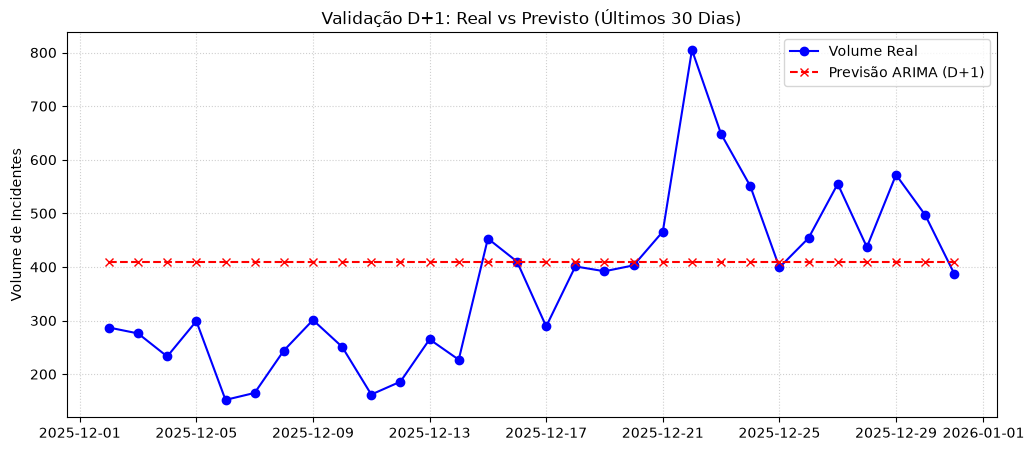

In [40]:
mae = mean_absolute_error(valores_reais, previsoes_d1)
rmse = np.sqrt(mean_squared_error(valores_reais, previsoes_d1))

print("\n--- Performance da Baseline ARIMA(7,1,6) ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} incidentes")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} incidentes")

# 4. Plotando o resultado para o PPT da Sprint 3
plt.figure(figsize=(12, 5))
plt.plot(teste.index, valores_reais, label='Volume Real', color='blue', marker='o')
plt.plot(teste.index, previsoes_d1, label='Previsão ARIMA (D+1)', color='red', linestyle='--', marker='x')
plt.title("Validação D+1: Real vs Previsto (Últimos 30 Dias)")
plt.ylabel("Volume de Incidentes")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

O Problema: Tentamos modelar a série univariada com um ARIMA clássico.

A Limitação: Devido à alta volatilidade e ausência de sazonalidade semanal no modelo univariado rígido, a baseline gerou uma predição constante com um MAE alto.

O Próximo Passo (Evolução): Para capturar os picos de volume que acontecem em dias específicos e o impacto das outras variáveis do Dicionário de Dados, evoluímos para um modelo baseado em árvores (como o XGBoost com lags) ou Prophet.

# Ponderação sobre Modelos

O Problema do SARIMAX: O SARIMAX é excelente para poucas variáveis exógenas numéricas (ex: temperatura, taxa de juros). Se você tentar "injetar" dezenas de colunas categóricas (como o volume de incidentes do Team14 na Categoria X) em um SARIMAX, ele sofrerá com a "maldição da dimensionalidade". Os cálculos matemáticos do ARIMA ficam extremamente lentos e complexos com muitas variáveis.

A Força das Árvores (XGBoost / LightGBM): Com esse nível de granularidade do dicionário, modelos de Gradient Boosting (como XGBoost) brilham. Eles não se importam se a série é estacionária ou não, e lidam incrivelmente bem com centenas de colunas de contagem agrupadas (lags). Para prever a sobrecarga de um time específico ou a quebra de KPI de um produto, o XGBoost supera o SARIMAX na maioria dos cenários do mundo real de ITSM.

# Prophet

In [41]:
df_prophet = df_inc2.reset_index()
df_prophet

,data,qtd_incidentes
0,2024-12-27,49
1,2024-12-28,4
2,2024-12-29,6
3,2024-12-30,19
4,2024-12-31,17
...,...,...
365,2025-12-27,555
366,2025-12-28,437
367,2025-12-29,572
368,2025-12-30,497


In [42]:
df_prophet = df_prophet[['data', 'qtd_incidentes']]
df_prophet.columns = ['ds', 'y']

In [43]:
df_prophet.columns

Index(['ds', 'y'], dtype='str')

## Separando Treino e Teste 

In [44]:
tam_teste = 30
train = df_prophet.iloc[:-tam_teste]
test = df_prophet.iloc[-tam_teste:]

print("Iniciando o treinamento do Prophet...")


Iniciando o treinamento do Prophet...


In [45]:
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

modelo_prophet.add_country_holidays(country_name='BR')

In [46]:
modelo_prophet.fit(train)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
22:08:04 - cmdstanpy - INFO - Chain [1] start processing
22:08:04 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
futuro = modelo_prophet.make_future_dataframe(periods=tam_teste, freq='D')

In [48]:
previsao = modelo_prophet.predict(futuro)

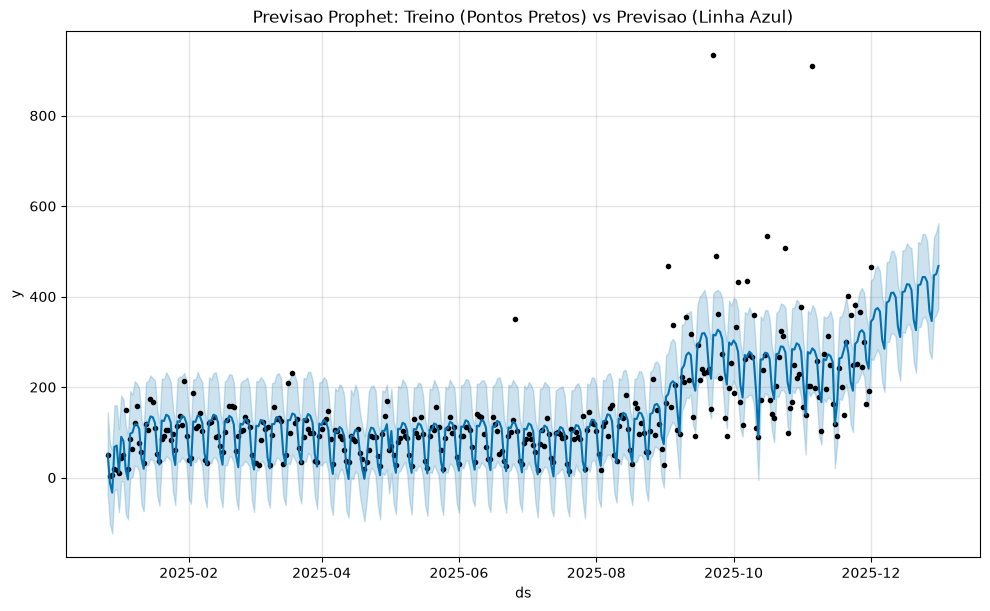

In [49]:
fig1 = modelo_prophet.plot(previsao)
plt.title('Previsao Prophet: Treino (Pontos Pretos) vs Previsao (Linha Azul)')
plt.show()

In [52]:
previsoes_teste = previsao.iloc[-tam_teste:]['yhat'].values

In [53]:
valores_reais = test['y'].values

In [56]:
mae = mean_absolute_error(valores_reais, previsoes_teste)
rmse = np.sqrt(mean_squared_error(valores_reais, previsoes_teste))

print("\n--- Performance do Modelo Prophet ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} incidentes")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} incidentes")


--- Performance do Modelo Prophet ---
MAE (Erro Médio Absoluto): 112.40 incidentes
RMSE (Raiz do Erro Quadrático Médio): 137.32 incidentes


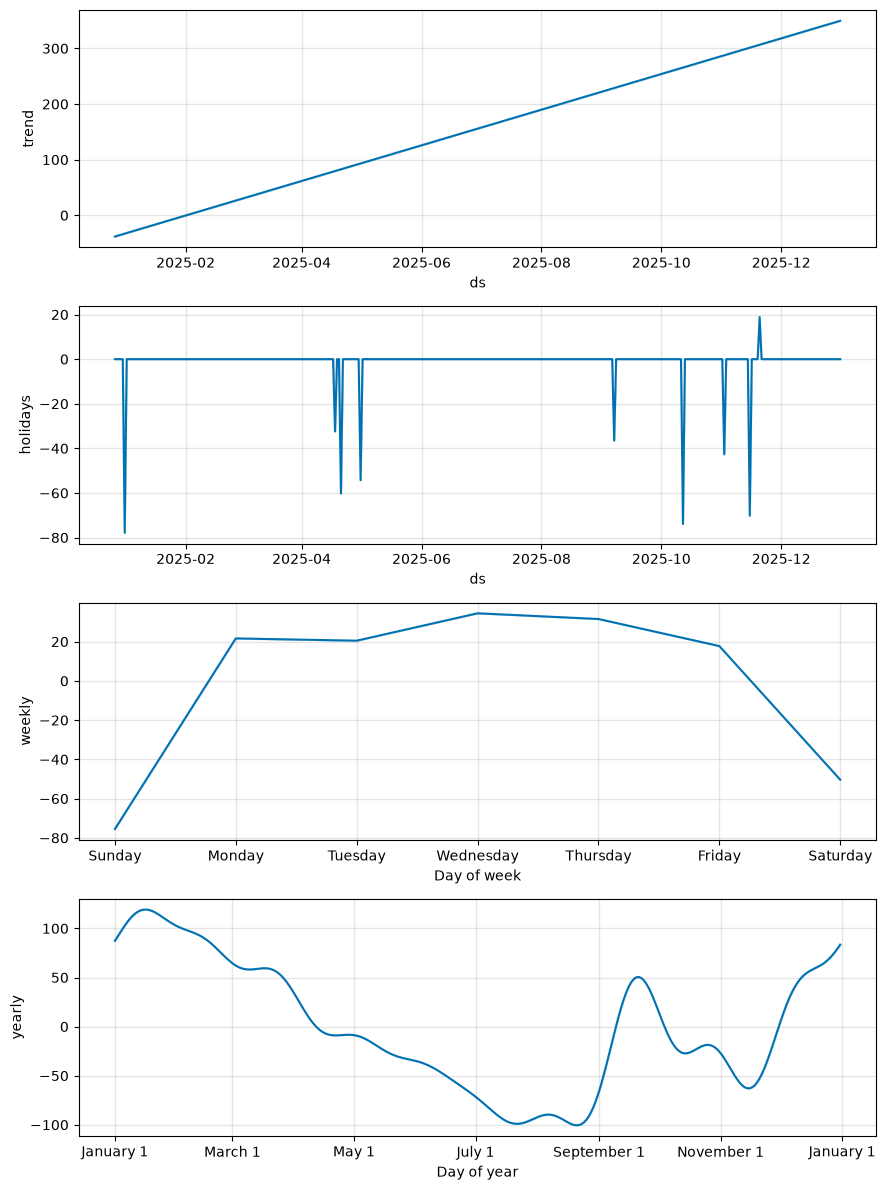

In [55]:
fig2 = modelo_prophet.plot_components(previsao)
plt.show()

## Impacto de Outliers

O "Elefante na Sala": O que o gráfico nos revela
Observando a imagem que você enviou, o motivo para os erros de MAE e RMSE continuarem altos está escancarado na distribuição dos pontos pretos (os dados reais). O seu dataset sofreu uma Quebra Estrutural (Structural Break) massiva.

Note que entre janeiro e agosto, o volume diário flutuava de forma comportada em torno de 100 incidentes. De repente, a partir de setembro, o comportamento da operação mudou completamente: a média saltou para a casa dos 300 incidentes, com picos violentos (outliers) batendo quase 900 chamados em dias específicos (aqueles dois pontos isolados no topo direito).

Esses dois pontos isolados próximos a 900 são os grandes vilões que estão explodindo o seu RMSE (que pune severamente erros grandes). O Prophet tenta traçar uma linha suave para entender a tendência anual, mas esse salto abrupto no final do ano "confunde" a matemática do modelo.

Estratégia 2: Tratamento de Outliers (Clipping)
Aqueles dois dias com 900 chamados provavelmente foram instabilidades sistêmicas massivas (quedas de servidor, rompimentos de rede). Para uma previsão baseline de rotina, esses dias devem ser tratados. Podemos substituir qualquer volume acima do percentil 95 (ex: tudo acima de 500) pelo limite máximo aceitável, ancorando a variância do modelo.

In [57]:
limite_p95 = df_prophet['y'].quantile(0.95)
print(f"Limitando outliers acima de: {limite_p95:.0f} incidentes")

Limitando outliers acima de: 422 incidentes


In [58]:
df_prophet['y'] = np.clip(df_prophet['y'], a_min=None, a_max=limite_p95)

## Separando Treino e Teste 

In [59]:
tam_teste = 30
train = df_prophet.iloc[:-tam_teste]
test = df_prophet.iloc[-tam_teste:]

print("Iniciando o treinamento do Prophet...")


Iniciando o treinamento do Prophet...


In [60]:
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

modelo_prophet.add_country_holidays(country_name='BR')

In [61]:
modelo_prophet.fit(train)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
22:27:05 - cmdstanpy - INFO - Chain [1] start processing
22:27:05 - cmdstanpy - INFO - Chain [1] done processing


In [62]:
futuro = modelo_prophet.make_future_dataframe(periods=tam_teste, freq='D')

In [63]:
previsao = modelo_prophet.predict(futuro)

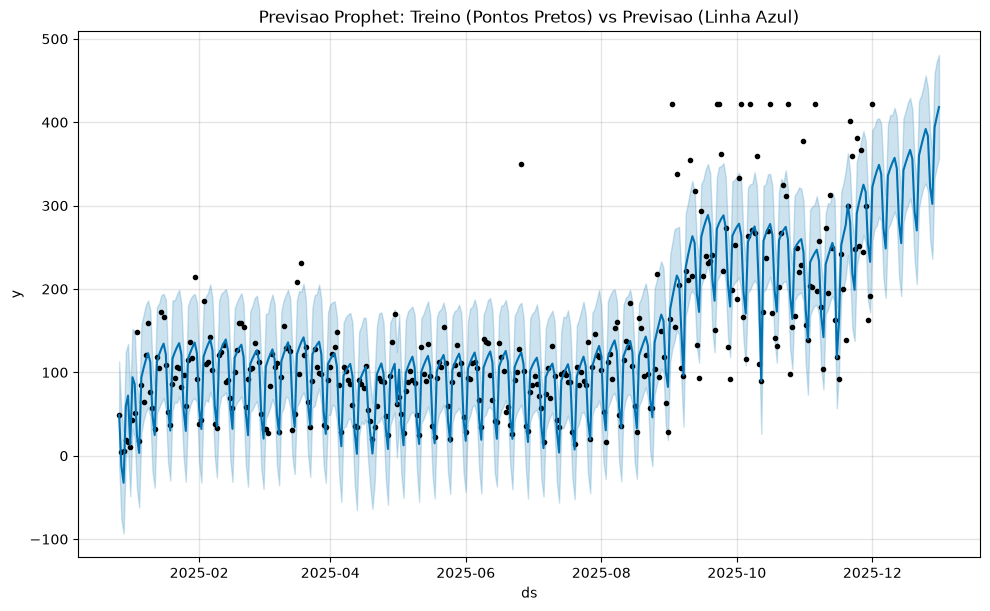

In [64]:
fig1 = modelo_prophet.plot(previsao)
plt.title('Previsao Prophet: Treino (Pontos Pretos) vs Previsao (Linha Azul)')
plt.show()

In [65]:
previsoes_teste = previsao.iloc[-tam_teste:]['yhat'].values

In [66]:
valores_reais = test['y'].values

In [67]:
mae = mean_absolute_error(valores_reais, previsoes_teste)
rmse = np.sqrt(mean_squared_error(valores_reais, previsoes_teste))

print("\n--- Performance do Modelo Prophet ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} incidentes")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} incidentes")


--- Performance do Modelo Prophet ---
MAE (Erro Médio Absoluto): 71.22 incidentes
RMSE (Raiz do Erro Quadrático Médio): 84.87 incidentes


# Correlações e Agrupamentos (foco em categorias)

# Distribuição e Outliers